# Intent Classification Chatbot: End-to-End NLP System from Classical ML to Transformers


### Description

This project builds an **end-to-end Intent Classification system that can understand user messages and classify them into predefined intents** such as booking a flight, canceling an order, checking account status, or requesting support.

The goal is to simulate the core intelligence behind modern chatbots used in customer service and virtual assistants.

The project follows a complete NLP pipeline, starting from text preprocessing and feature engineering, moving through traditional machine learning models (TF-IDF + Logistic Regression, SVM), and extending to deep learning models (LSTM/MLP) and transformer-based models (BERT).

A full comparison of models is performed to analyze performance trade-offs between accuracy, speed, and complexity. Finally, the best model is deployed in a simple API or chat interface to simulate real-world usage.

</br>

### Dataset Info

Primary Dataset: CLINC150 Intent Classification Dataset

The project uses the CLINC150 dataset, a widely used benchmark dataset for intent classification in conversational AI systems.

**Dataset Overview**:
- Total Intents: 150 different intent classes
- Total Samples: ~23,700 utterances
- Domains Covered: Banking, travel, credit cards, online shopping, utilities, messaging, etc.
- Language: English
- Type: Supervised text classification dataset

### Goal
Build the following models:
```
TF-IDF + Logistic Regression
          ↓
TF-IDF + Neural Network
          ↓
BERT Fine-Tuning
          ↓
Comparison & Analysis
```

## Loading Dataset and understanding Dataset

- loading dataset from HuggingFace
- understanding:
  - label encoding,
  - dataset structure,
  - class mapping system
  - class distribution: Is the dataset balanced or biased toward some intents?

In [1]:
from collections import Counter

from datasets import load_dataset

import matplotlib.pyplot as plt


dataset = load_dataset("clinc/clinc_oos", "plus")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/24.0k [00:00<?, ?B/s]

plus/train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

plus/validation-00000-of-00001.parquet:   0%|          | 0.00/77.8k [00:00<?, ?B/s]

plus/test-00000-of-00001.parquet:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

In [2]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})

In [3]:
len(dataset)

3

In [4]:
dataset["train"][0]

{'text': 'what expression would i use to say i love you if i were an italian',
 'intent': 61}

In [5]:
text, intent = dataset["train"][0]["text"], dataset["train"][0]["intent"]

In [6]:
text

'what expression would i use to say i love you if i were an italian'

In [7]:
intent

61

In [8]:
dataset["validation"][0]

{'text': 'in spanish, meet me tomorrow is said how', 'intent': 61}

In [9]:
dataset["test"][0]

{'text': 'how would you say fly in italian', 'intent': 61}

In [10]:
features = dataset["train"].features
features

{'text': Value('string'),
 'intent': ClassLabel(names=['restaurant_reviews', 'nutrition_info', 'account_blocked', 'oil_change_how', 'time', 'weather', 'redeem_rewards', 'interest_rate', 'gas_type', 'accept_reservations', 'smart_home', 'user_name', 'report_lost_card', 'repeat', 'whisper_mode', 'what_are_your_hobbies', 'order', 'jump_start', 'schedule_meeting', 'meeting_schedule', 'freeze_account', 'what_song', 'meaning_of_life', 'restaurant_reservation', 'traffic', 'make_call', 'text', 'bill_balance', 'improve_credit_score', 'change_language', 'no', 'measurement_conversion', 'timer', 'flip_coin', 'do_you_have_pets', 'balance', 'tell_joke', 'last_maintenance', 'exchange_rate', 'uber', 'car_rental', 'credit_limit', 'oos', 'shopping_list', 'expiration_date', 'routing', 'meal_suggestion', 'tire_change', 'todo_list', 'card_declined', 'rewards_balance', 'change_accent', 'vaccines', 'reminder_update', 'food_last', 'change_ai_name', 'bill_due', 'who_do_you_work_for', 'share_location', 'internat

In [11]:
class_names = features["intent"].names
class_names
# there is a oos intent stands for "out of scope" it is important because In production chatbots, users often ask things that are not supported.

['restaurant_reviews',
 'nutrition_info',
 'account_blocked',
 'oil_change_how',
 'time',
 'weather',
 'redeem_rewards',
 'interest_rate',
 'gas_type',
 'accept_reservations',
 'smart_home',
 'user_name',
 'report_lost_card',
 'repeat',
 'whisper_mode',
 'what_are_your_hobbies',
 'order',
 'jump_start',
 'schedule_meeting',
 'meeting_schedule',
 'freeze_account',
 'what_song',
 'meaning_of_life',
 'restaurant_reservation',
 'traffic',
 'make_call',
 'text',
 'bill_balance',
 'improve_credit_score',
 'change_language',
 'no',
 'measurement_conversion',
 'timer',
 'flip_coin',
 'do_you_have_pets',
 'balance',
 'tell_joke',
 'last_maintenance',
 'exchange_rate',
 'uber',
 'car_rental',
 'credit_limit',
 'oos',
 'shopping_list',
 'expiration_date',
 'routing',
 'meal_suggestion',
 'tire_change',
 'todo_list',
 'card_declined',
 'rewards_balance',
 'change_accent',
 'vaccines',
 'reminder_update',
 'food_last',
 'change_ai_name',
 'bill_due',
 'who_do_you_work_for',
 'share_location',
 'int

In [12]:
class_names[intent]

'translate'

In [13]:
# printing a sample data for understanding
print(f"text: {text}")
print(f"intent id: {intent}")
print(f"classname: {class_names[intent]}")

text: what expression would i use to say i love you if i were an italian
intent id: 61
classname: translate


In [14]:
id2label = {i: label for i, label in enumerate(class_names)}
label2id = {label: i for i, label in enumerate(class_names)}

In [15]:
id2label

{0: 'restaurant_reviews',
 1: 'nutrition_info',
 2: 'account_blocked',
 3: 'oil_change_how',
 4: 'time',
 5: 'weather',
 6: 'redeem_rewards',
 7: 'interest_rate',
 8: 'gas_type',
 9: 'accept_reservations',
 10: 'smart_home',
 11: 'user_name',
 12: 'report_lost_card',
 13: 'repeat',
 14: 'whisper_mode',
 15: 'what_are_your_hobbies',
 16: 'order',
 17: 'jump_start',
 18: 'schedule_meeting',
 19: 'meeting_schedule',
 20: 'freeze_account',
 21: 'what_song',
 22: 'meaning_of_life',
 23: 'restaurant_reservation',
 24: 'traffic',
 25: 'make_call',
 26: 'text',
 27: 'bill_balance',
 28: 'improve_credit_score',
 29: 'change_language',
 30: 'no',
 31: 'measurement_conversion',
 32: 'timer',
 33: 'flip_coin',
 34: 'do_you_have_pets',
 35: 'balance',
 36: 'tell_joke',
 37: 'last_maintenance',
 38: 'exchange_rate',
 39: 'uber',
 40: 'car_rental',
 41: 'credit_limit',
 42: 'oos',
 43: 'shopping_list',
 44: 'expiration_date',
 45: 'routing',
 46: 'meal_suggestion',
 47: 'tire_change',
 48: 'todo_list

In [16]:
label2id

{'restaurant_reviews': 0,
 'nutrition_info': 1,
 'account_blocked': 2,
 'oil_change_how': 3,
 'time': 4,
 'weather': 5,
 'redeem_rewards': 6,
 'interest_rate': 7,
 'gas_type': 8,
 'accept_reservations': 9,
 'smart_home': 10,
 'user_name': 11,
 'report_lost_card': 12,
 'repeat': 13,
 'whisper_mode': 14,
 'what_are_your_hobbies': 15,
 'order': 16,
 'jump_start': 17,
 'schedule_meeting': 18,
 'meeting_schedule': 19,
 'freeze_account': 20,
 'what_song': 21,
 'meaning_of_life': 22,
 'restaurant_reservation': 23,
 'traffic': 24,
 'make_call': 25,
 'text': 26,
 'bill_balance': 27,
 'improve_credit_score': 28,
 'change_language': 29,
 'no': 30,
 'measurement_conversion': 31,
 'timer': 32,
 'flip_coin': 33,
 'do_you_have_pets': 34,
 'balance': 35,
 'tell_joke': 36,
 'last_maintenance': 37,
 'exchange_rate': 38,
 'uber': 39,
 'car_rental': 40,
 'credit_limit': 41,
 'oos': 42,
 'shopping_list': 43,
 'expiration_date': 44,
 'routing': 45,
 'meal_suggestion': 46,
 'tire_change': 47,
 'todo_list': 4

In [17]:
# checking class distribution
'''
Class imbalance issues
If one class dominates:
- model becomes biased
- accuracy becomes misleading

Dataset health
we should confirm:
- enough samples per class
- no missing intents
- good training stability
'''

## counting occurrences per class
train_intents = dataset["train"]["intent"]
counter = Counter(train_intents)

In [18]:
train_intents

Column([61, 61, 61, 61, 61])

In [19]:
counter

Counter({61: 100,
         133: 100,
         32: 100,
         139: 100,
         22: 100,
         64: 100,
         81: 100,
         128: 100,
         97: 100,
         28: 100,
         129: 100,
         29: 100,
         79: 100,
         90: 100,
         4: 100,
         103: 100,
         80: 100,
         33: 100,
         144: 100,
         77: 100,
         125: 100,
         115: 100,
         121: 100,
         3: 100,
         23: 100,
         35: 100,
         85: 100,
         20: 100,
         100: 100,
         96: 100,
         78: 100,
         11: 100,
         66: 100,
         118: 100,
         68: 100,
         145: 100,
         50: 100,
         111: 100,
         71: 100,
         101: 100,
         69: 100,
         91: 100,
         113: 100,
         13: 100,
         142: 100,
         123: 100,
         107: 100,
         149: 100,
         74: 100,
         65: 100,
         76: 100,
         119: 100,
         98: 100,
         30: 100,
         1

In [20]:
len(counter)

151

In [21]:
## converting to readable format
distribution = {
    class_names[i]: count
    for i, count in counter.items()
}

In [22]:
distribution

{'translate': 100,
 'transfer': 100,
 'timer': 100,
 'definition': 100,
 'meaning_of_life': 100,
 'insurance_change': 100,
 'find_phone': 100,
 'travel_alert': 100,
 'pto_request': 100,
 'improve_credit_score': 100,
 'fun_fact': 100,
 'change_language': 100,
 'payday': 100,
 'replacement_card_duration': 100,
 'time': 100,
 'application_status': 100,
 'flight_status': 100,
 'flip_coin': 100,
 'change_user_name': 100,
 'where_are_you_from': 100,
 'shopping_list_update': 100,
 'what_can_i_ask_you': 100,
 'maybe': 100,
 'oil_change_how': 100,
 'restaurant_reservation': 100,
 'balance': 100,
 'confirm_reservation': 100,
 'freeze_account': 100,
 'rollover_401k': 100,
 'who_made_you': 100,
 'distance': 100,
 'user_name': 100,
 'timezone': 100,
 'next_song': 100,
 'transactions': 100,
 'restaurant_suggestion': 100,
 'rewards_balance': 100,
 'pay_bill': 100,
 'spending_history': 100,
 'pto_request_status': 100,
 'credit_score': 100,
 'new_card': 100,
 'lost_luggage': 100,
 'repeat': 100,
 'mpg'

In [23]:
## printing sorted distribution
sorted_dist = dict(sorted(distribution.items(), key = lambda x: x[1], reverse = True))

for label, count in sorted_dist.items():
    print(label, ":", count)

oos : 250
translate : 100
transfer : 100
timer : 100
definition : 100
meaning_of_life : 100
insurance_change : 100
find_phone : 100
travel_alert : 100
pto_request : 100
improve_credit_score : 100
fun_fact : 100
change_language : 100
payday : 100
replacement_card_duration : 100
time : 100
application_status : 100
flight_status : 100
flip_coin : 100
change_user_name : 100
where_are_you_from : 100
shopping_list_update : 100
what_can_i_ask_you : 100
maybe : 100
oil_change_how : 100
restaurant_reservation : 100
balance : 100
confirm_reservation : 100
freeze_account : 100
rollover_401k : 100
who_made_you : 100
distance : 100
user_name : 100
timezone : 100
next_song : 100
transactions : 100
restaurant_suggestion : 100
rewards_balance : 100
pay_bill : 100
spending_history : 100
pto_request_status : 100
credit_score : 100
new_card : 100
lost_luggage : 100
repeat : 100
mpg : 100
oil_change_when : 100
yes : 100
travel_suggestion : 100
insurance : 100
todo_list_update : 100
reminder : 100
change_s

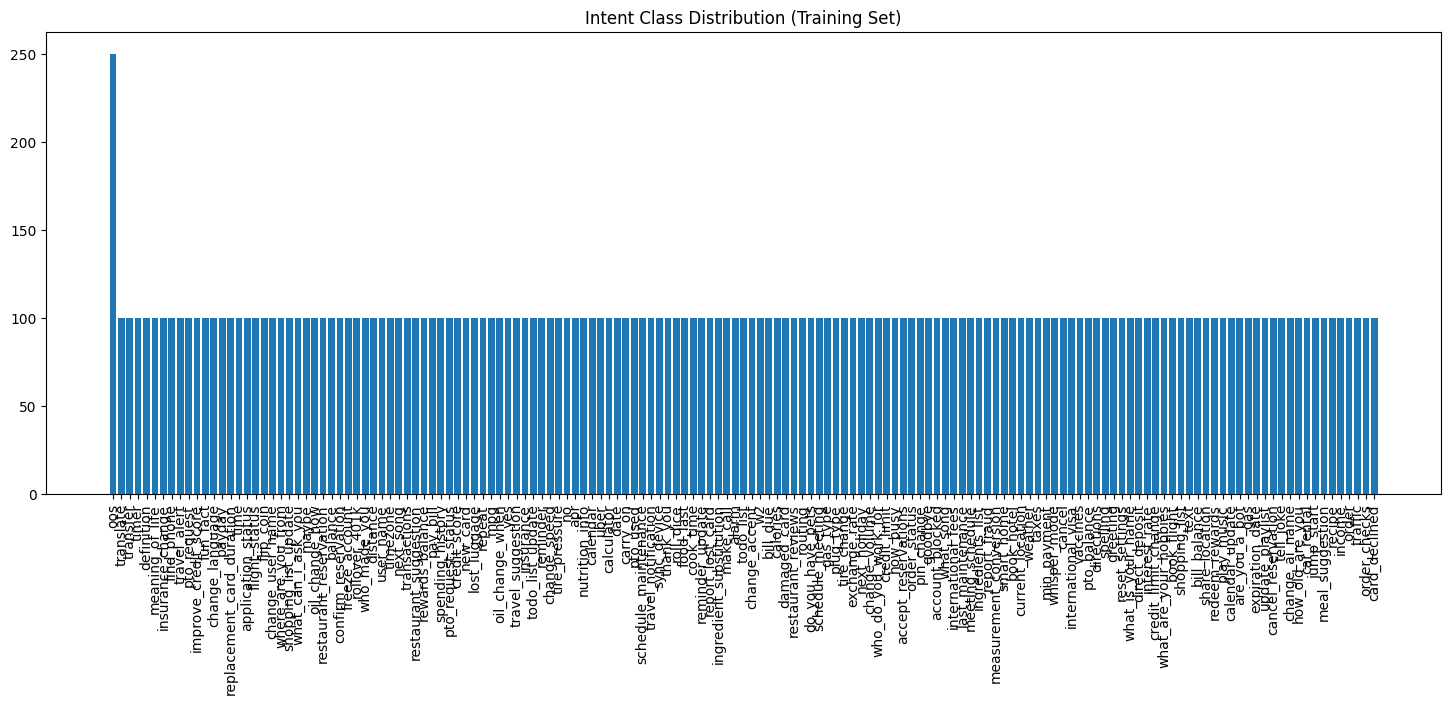

In [24]:
## visualization of the distribution
plt.figure(figsize = (18, 6))
plt.bar(sorted_dist.keys(), sorted_dist.values())
plt.xticks(rotation = 90)
plt.title("Intent Class Distribution (Training Set)")
plt.show()

## Cleaning and Preprocessing

**Preprocessing is model-dependent, not dataset-dependent**

for now i will keep a basic cleaning preprocess further as i will be created two pipeline for Traditional ML and for using transformer, i might do some cleaning and preprocessing accordingly to the pipeline. but for now a basic cleasing is ok

**For Traditional ML**: TF-IDF, Logistic Regression (model)
- Lowercasing
- Remove punctuation
- Remove special characters
- Optional: remove stopwords
- Optional: lemmatization

Because TF-IDF depends on exact words

</br>

**For Transformer**: BERT

No heavy preprocessing
- keep text almost raw
- maybe strip extra spaces

Because models like BERT: understand punctuation, use context and were trained on raw text

### Cleaning

In [25]:
def basic_clean(text):
    ''' removing extra space or whitespace present at the end '''
    return text.strip()

In [26]:
## further I should NOT modify the dataset directly instead i should create preprocessing functions
## per pipeline
'''
def preprocess_for_tfidf(text):
    # heavy cleaning
    return cleaned_text

def preprocess_for_bert(text):
    return text.strip()
'''

'\ndef preprocess_for_tfidf(text):\n    # heavy cleaning\n    return cleaned_text\n\ndef preprocess_for_bert(text):\n    return text.strip()\n'

### Preprocessing (Tokenization)

Tokenization is the process of converting raw text into smaller units called tokens. as computers cannot understand raw text directly we must then convert: `Text → Tokens → Numbers → Model`

There are three type:
1. Word tokenization: split by spaces
    - TF-IDF,
    - Bag of Words,
    - Logistic Regression etc...
2. Subword Tokenization: Break words into smaller meaningful parts (it's what model like BERT use)
    - e.g unbelievable ---> "un", "believ", "able"
3. Character Tokenization:
    - "book" → ["b", "o", "o", "k"] (not effective and it is rarely used)

</br>

**How Tokenization Works Internally**
- Step 1: Normalize text
  ```
  "I LOVE NLP!!!"
→ "i love nlp!!!"
  ```
- Step 2: Split into subwords
  ```
  "playing" → ["play", "##ing"]
  ```
- Step 3: Convert to IDs
  ```
  ["play", "##ing"] → [2345, 6789]
  ```
- Step 4: Add special tokens
  ```
  [CLS] I want to book [SEP]
  ```

</br>

Tokenization is NOT just splitting text. **It is how the model understands language**

#### Extracting text and labels

In [27]:
# extracting Text and Labels
train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["intent"]

val_texts = dataset["validation"]["text"]
val_labels = dataset["validation"]["intent"]

test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["intent"]

In [28]:
print(f"train_texts length: {len(train_texts)}")
print(f"train_labels length: {len(train_labels)}")
print(f"val_texts length: {len(val_texts)}")
print(f"val_labels length: {len(val_labels)}")
print(f"test_texts length: {len(test_texts)}")
print(f"test_labels length: {len(test_labels)}")

train_texts length: 15250
train_labels length: 15250
val_texts length: 3100
val_labels length: 3100
test_texts length: 5500
test_labels length: 5500


## Building a Traditional ML model baseline

**Logistic Regression Model**
because Logistic Regression is: the strongest classical NLP baseline, simple mathematically and it is surprisingly powerful for text classification

In [29]:
import re

from sklearn.feature_extraction.text import TfidfVectorizer

import torch

In [30]:
# extracting Text and Labels
train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["intent"]

val_texts = dataset["validation"]["text"]
val_labels = dataset["validation"]["intent"]

test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["intent"]

In [31]:
# preprocessing
def preprocess_for_tfidf(text):
    cleaned_text = text.lower()
    cleaned_text = re.sub(r"[^\w\s]", "", text)  # removing punctuation
    return cleaned_text

In [32]:
train_texts

Column(['what expression would i use to say i love you if i were an italian', "can you tell me how to say 'i do not speak much spanish', in spanish", "what is the equivalent of, 'life is good' in french", "tell me how to say, 'it is a beautiful morning' in italian", 'if i were mongolian, how would i say that i am a tourist'])

In [33]:
train_texts = [preprocess_for_tfidf(t) for t in train_texts]
val_texts = [preprocess_for_tfidf(t) for t in val_texts]
test_texts = [preprocess_for_tfidf(t) for t in test_texts]

In [34]:
train_texts

['what expression would i use to say i love you if i were an italian',
 'can you tell me how to say i do not speak much spanish in spanish',
 'what is the equivalent of life is good in french',
 'tell me how to say it is a beautiful morning in italian',
 'if i were mongolian how would i say that i am a tourist',
 'how do i say hotel in finnish',
 'i need you to translate the sentence we will be there soon into portuguese',
 'please tell me how to ask for a taxi in french',
 'can you tell me how i would say more bread please in french',
 'what is the correct way to say i am a visitor in french',
 'how would i say i dont know the answer in spanish',
 'i would like to know the proper way to greet an adult in portuguese',
 'what words would i use to tell someone i am lost if i were japanese',
 'how would i say thank you if i were russian',
 'can you tell me how i would normally say thank you as a french person',
 'i would like to know how to say hello in french',
 'if i were english how wo

In [35]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features = 5000, # limiting vocabulary size
    ngram_range = (1, 2) # considering unigrams and bigrams together
)

In [36]:
vectorizer

TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

In [37]:
# fitting vectorizer to our dataset in other to learn it token representation value vector :
# learning vocabulary and importance of words

# we fit on training dataset only
X_train = vectorizer.fit_transform(train_texts)

In [38]:
# transforming validation and testing dataset
X_val = vectorizer.transform(val_texts)
X_test = vectorizer.transform(test_texts)

In [39]:
type(X_train) # we might need to sparse X_train later as sparse matrix most values are 0

scipy.sparse._csr.csr_matrix

In [40]:
print(X_train.shape)

(15250, 5000)


In [41]:
# converting to PyTorch tensors

X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)

y_train_tensor = torch.tensor(train_labels, dtype=torch.long)
y_val_tensor = torch.tensor(val_labels, dtype=torch.long)
y_test_tensor = torch.tensor(test_labels, dtype=torch.long)

`toarray()` converts sparse to **dense**. for this dataset it is ok because the dataset is manageable but in large datasets it can cause memory issue

In [42]:
X_train_tensor[0]

tensor([0., 0., 0.,  ..., 0., 0., 0.])

In [43]:
y_train_tensor[0]

tensor(61)

In [44]:
class_names[y_train_tensor[0]]

'translate'

In [45]:
# creating PyTorch Dataset
from torch.utils.data import Dataset, DataLoader

class IntentDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [46]:
train_dataset = IntentDataset(X_train_tensor, y_train_tensor)
val_dataset = IntentDataset(X_val_tensor, y_val_tensor)

In [47]:
len(train_dataset), len(val_dataset)

(15250, 3100)

In [48]:
train_dataset[0], val_dataset[0]

((tensor([0., 0., 0.,  ..., 0., 0., 0.]), tensor(61)),
 (tensor([0., 0., 0.,  ..., 0., 0., 0.]), tensor(61)))

In [49]:
# dataloading, applying DataLoader
train_loader = DataLoader(
                  train_dataset,
                  batch_size = 32,
                  shuffle = True
               )
val_loader = DataLoader(
                  val_dataset,
                  batch_size = 32
             )

In [50]:
# building the Logistic Regression Model
import torch
import torch.nn as nn

In [51]:
## defining the model
class LogisticRegressionModel(nn.Module):
    '''
      input_dim: number of TF-IDF features
      num_classes: Number of intent labels

      applying:
        nn.Linear: This is the actual Logistic Regression equation: y = Wx + b
                  x: TF-IDF vector
                  W: learned weights
                  b: bias
    '''
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        outputs = self.linear(x)
        return outputs

In [52]:
## initializing the model
input_dim = X_train_tensor.shape[1]
num_classes = len(class_names)

model = LogisticRegressionModel(input_dim, num_classes)

In [53]:
model

LogisticRegressionModel(
  (linear): Linear(in_features=5000, out_features=151, bias=True)
)

In [54]:
## defining criterion or loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [55]:
## training loop

num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

Epoch [1/30] Loss: 4.7696
Epoch [2/30] Loss: 4.1884
Epoch [3/30] Loss: 3.6387
Epoch [4/30] Loss: 3.1229
Epoch [5/30] Loss: 2.6513
Epoch [6/30] Loss: 2.2342
Epoch [7/30] Loss: 1.8758
Epoch [8/30] Loss: 1.5764
Epoch [9/30] Loss: 1.3299
Epoch [10/30] Loss: 1.1286
Epoch [11/30] Loss: 0.9649
Epoch [12/30] Loss: 0.8310
Epoch [13/30] Loss: 0.7218
Epoch [14/30] Loss: 0.6314
Epoch [15/30] Loss: 0.5565
Epoch [16/30] Loss: 0.4938
Epoch [17/30] Loss: 0.4413
Epoch [18/30] Loss: 0.3962
Epoch [19/30] Loss: 0.3579
Epoch [20/30] Loss: 0.3248
Epoch [21/30] Loss: 0.2961
Epoch [22/30] Loss: 0.2713
Epoch [23/30] Loss: 0.2495
Epoch [24/30] Loss: 0.2303
Epoch [25/30] Loss: 0.2133
Epoch [26/30] Loss: 0.1982
Epoch [27/30] Loss: 0.1847
Epoch [28/30] Loss: 0.1726
Epoch [29/30] Loss: 0.1619
Epoch [30/30] Loss: 0.1519


In [56]:
# evaluation

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for inputs, labels in val_loader:
        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

In [57]:
# final accuracy

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 87.23%


In [58]:
# Evaluation analysis

## Evaluation Prediction Loop
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for inputs, labels in val_loader:
        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [59]:
len(all_preds), len(all_labels)

(3100, 3100)

In [60]:
# Precision / Recall / F1-score

from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names = class_names
)

print(report)

                           precision    recall  f1-score   support

       restaurant_reviews       0.83      0.75      0.79        20
           nutrition_info       0.75      0.60      0.67        20
          account_blocked       1.00      0.70      0.82        20
           oil_change_how       0.95      1.00      0.98        20
                     time       0.90      0.90      0.90        20
                  weather       0.85      0.85      0.85        20
           redeem_rewards       1.00      0.85      0.92        20
            interest_rate       1.00      0.95      0.97        20
                 gas_type       0.95      0.95      0.95        20
      accept_reservations       0.89      0.80      0.84        20
               smart_home       0.95      0.90      0.92        20
                user_name       0.74      0.85      0.79        20
         report_lost_card       0.95      1.00      0.98        20
                   repeat       0.82      0.90      0.86     

**Precision**: When model predicts a class, how often is it correct?

**Recall**: How many real samples did the model successfully find?

**F1 Score**: Balances precision + recall

</br>

high precision and high recall, the better.

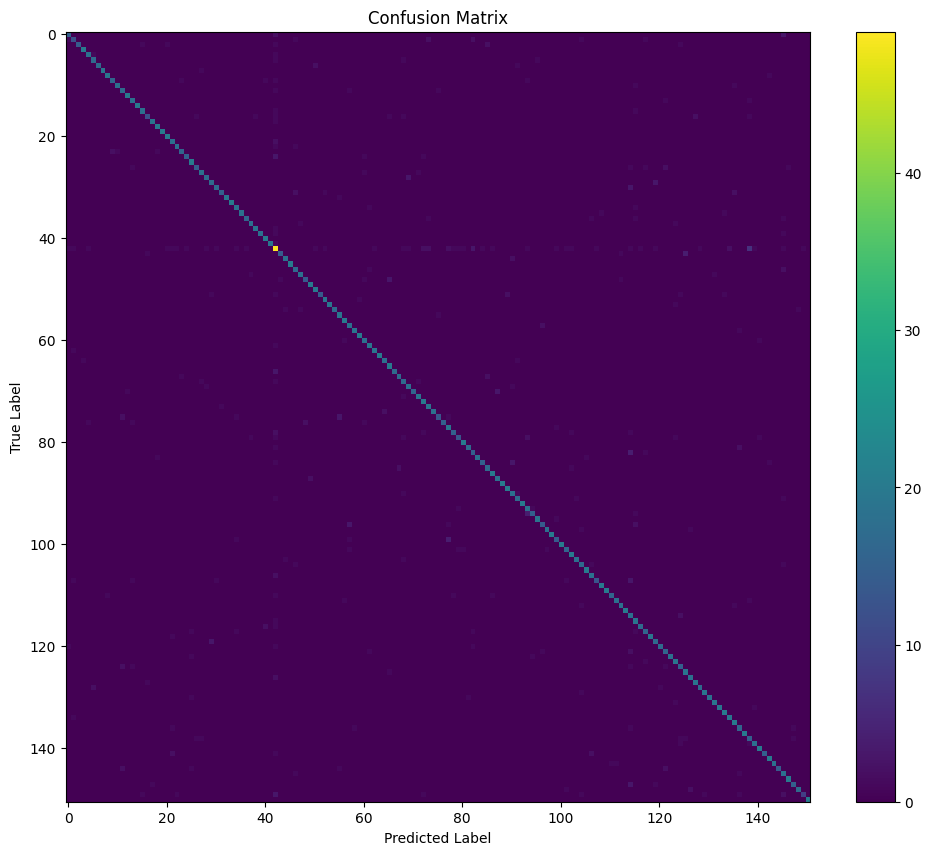

In [61]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)


# Since 151 classes is huge, we will make a compact visualization.
plt.figure(figsize = (12,10))
plt.imshow(cm, aspect = 'auto')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.show()


An Ideal confusion matrix: Should show a Strong diagonal line because correct predictions accumulate on diagonal.

Hence this Logistic Regression Model built is good.

In [62]:
# Error analysis

val_texts_raw = dataset["validation"]["text"]

wrong_samples = []

model.eval()
index = 0

with torch.no_grad():

    for inputs, labels in val_loader:
        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        batch_size = labels.size(0)

        for i in range(batch_size):
            true_label = labels[i].item()
            pred_label = predicted[i].item()

            if true_label != pred_label:
                wrong_samples.append({
                    "text": val_texts_raw[index],
                    "true": class_names[true_label],
                    "predicted": class_names[pred_label]
                })

            index += 1

In [63]:
wrong_samples

[{'text': 'how do i ask about the weather in chinese',
  'true': 'translate',
  'predicted': 'oos'},
 {'text': "i'd like to set a new timer",
  'true': 'timer',
  'predicted': 'change_ai_name'},
 {'text': 'may i please have a definition for the work churlish',
  'true': 'definition',
  'predicted': 'thank_you'},
 {'text': 'can you tell me what a septuagenarian is',
  'true': 'definition',
  'predicted': 'calculator'},
 {'text': 'what do you think we are on earth for',
  'true': 'meaning_of_life',
  'predicted': 'meal_suggestion'},
 {'text': 'why are humans on earth',
  'true': 'meaning_of_life',
  'predicted': 'oos'},
 {'text': 'can you tell me how do i get new insurance',
  'true': 'insurance_change',
  'predicted': 'new_card'},
 {'text': 'tell me how to change my policy',
  'true': 'insurance_change',
  'predicted': 'oil_change_how'},
 {'text': 'what did i do with my phone',
  'true': 'find_phone',
  'predicted': 'oos'},
 {'text': "tell me my phone's location",
  'true': 'find_phone'

In [64]:
len(wrong_samples)

396

In [65]:
# viewing errors
for sample in wrong_samples[:10]:

    print("TEXT:", sample["text"])
    print("TRUE:", sample["true"])
    print("PRED:", sample["predicted"])
    print("-" * 50)

TEXT: how do i ask about the weather in chinese
TRUE: translate
PRED: oos
--------------------------------------------------
TEXT: i'd like to set a new timer
TRUE: timer
PRED: change_ai_name
--------------------------------------------------
TEXT: may i please have a definition for the work churlish
TRUE: definition
PRED: thank_you
--------------------------------------------------
TEXT: can you tell me what a septuagenarian is
TRUE: definition
PRED: calculator
--------------------------------------------------
TEXT: what do you think we are on earth for
TRUE: meaning_of_life
PRED: meal_suggestion
--------------------------------------------------
TEXT: why are humans on earth
TRUE: meaning_of_life
PRED: oos
--------------------------------------------------
TEXT: can you tell me how do i get new insurance
TRUE: insurance_change
PRED: new_card
--------------------------------------------------
TEXT: tell me how to change my policy
TRUE: insurance_change
PRED: oil_change_how
----------

We could interpret or infer that these errors are due to:
- ambiguous intents:
  ```
  ex:
  "change my reservation"
  ```
  could mean modify_booking or cancel_booking

</br>

- missing context: TF-IDF struggles with semantic meaning and intent nuance

</br>

- vocabulary overlap:
    ```
    ex:
    book flight
    cancel flight
    change flight
    ```
    are very similar vocabulary.

## Building a Neural Network baseline in PyTorch
TF-IDF + Neural Network

</br>

**architecture:** Simple Feedforward Neural Network (Multi-Layer Perceptron (MLP))
```
5000 TF-IDF Features
          ↓
     Linear Layer
          ↓
        ReLU
          ↓
     Hidden Layer
          ↓
        ReLU
          ↓
Output Layer (150 intents)
```

We are still using TF-IDF features. The only thing changing is:
```
Logistic Regression
      ↓
Neural Network
```

That can help answering to *Does a neural network help if the representation stays the same?*

In [66]:
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [67]:
# extracting Text and Labels

train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["intent"]

val_texts = dataset["validation"]["text"]
val_labels = dataset["validation"]["intent"]

test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["intent"]

In [68]:
# preprocessing

def preprocess_for_tfidf(text):
    cleaned_text = text.lower()
    cleaned_text = re.sub(r"[^\w\s]", "", text)  # removing punctuation
    return cleaned_text

In [69]:
# TF-IDF Vectorization

vectorizer = TfidfVectorizer(
    max_features = 5000,
    ngram_range = (1, 2)
)

In [70]:
# fitting vectorizer to our dataset

X_train = vectorizer.fit_transform(train_texts)

# transforming validation and testing dataset

X_val = vectorizer.transform(val_texts)
X_test = vectorizer.transform(test_texts)

In [71]:
# converting to PyTorch tensors

X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)

y_train_tensor = torch.tensor(train_labels, dtype=torch.long)
y_val_tensor = torch.tensor(val_labels, dtype=torch.long)
y_test_tensor = torch.tensor(test_labels, dtype=torch.long)

In [72]:
# creating PyTorch Dataset

class IntentDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [73]:
train_dataset = IntentDataset(X_train_tensor, y_train_tensor)
val_dataset = IntentDataset(X_val_tensor, y_val_tensor)

In [74]:
# dataloading, applying DataLoader

train_loader = DataLoader(
                  train_dataset,
                  batch_size = 32,
                  shuffle = True
               )
val_loader = DataLoader(
                  val_dataset,
                  batch_size = 32
             )

In [75]:
# building the model

class IntentMLP(nn.Module):
    '''
    512 hidden units taken
    nn.ReLU() activation function for adding non-linearity
    '''
    def __init__(self, input_dim, num_classes):

        super().__init__()

        self.linear1 = nn.Linear(input_dim, 512)
        self.relu1 = nn.ReLU()

        self.linear2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()

        self.linear3 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.linear1(x)
        print(f"Linear 1 output shape: {x.shape}")
        x = self.relu1(x)
        print(f"ReLU 1 output shape: {x.shape}")
        x = self.linear2(x)
        print(f"Linear 2 output shape: {x.shape}")
        x = self.relu2(x)
        print(f"ReLU 2 output shape: {x.shape}")
        x = self.linear3(x)
        return x

In [76]:
# running few tests to check the network dimension break downs
x = train_dataset[0][0]
x.shape

torch.Size([5000])

In [77]:
len(class_names)

151

In [78]:
test_model = IntentMLP(x.shape[0], len(class_names))
test_model

IntentMLP(
  (linear1): Linear(in_features=5000, out_features=512, bias=True)
  (relu1): ReLU()
  (linear2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (linear3): Linear(in_features=256, out_features=151, bias=True)
)

In [79]:
output = test_model(x)

Linear 1 output shape: torch.Size([512])
ReLU 1 output shape: torch.Size([512])
Linear 2 output shape: torch.Size([256])
ReLU 2 output shape: torch.Size([256])


In [80]:
class IntentMLP(nn.Module):
    '''
    512 hidden units taken
    '''
    def __init__(self, input_dim, num_classes):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.network(x)

In [81]:
# initializing the model

input_dim = X_train_tensor.shape[1]
num_classes = len(class_names)

model = IntentMLP(
    input_dim = input_dim,
    num_classes = num_classes
)

In [82]:
# defining loss function and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [83]:
train_losses = []
val_accuracies = []

In [84]:
# validation function

def evaluate(model, dataloader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, labels in dataloader:

            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [85]:
# training loop

num_epochs = 30

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for inputs, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    val_acc = evaluate(model, val_loader)

    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 1/30 | Loss: 2.2500 | Val Acc: 84.23%
Epoch 2/30 | Loss: 0.2535 | Val Acc: 86.68%
Epoch 3/30 | Loss: 0.1085 | Val Acc: 86.90%
Epoch 4/30 | Loss: 0.0623 | Val Acc: 86.74%
Epoch 5/30 | Loss: 0.0419 | Val Acc: 87.03%
Epoch 6/30 | Loss: 0.0337 | Val Acc: 86.58%
Epoch 7/30 | Loss: 0.0282 | Val Acc: 85.81%
Epoch 8/30 | Loss: 0.0264 | Val Acc: 86.97%
Epoch 9/30 | Loss: 0.0198 | Val Acc: 86.29%
Epoch 10/30 | Loss: 0.0209 | Val Acc: 86.74%
Epoch 11/30 | Loss: 0.0194 | Val Acc: 86.61%
Epoch 12/30 | Loss: 0.0218 | Val Acc: 86.26%
Epoch 13/30 | Loss: 0.0167 | Val Acc: 86.81%
Epoch 14/30 | Loss: 0.0179 | Val Acc: 86.55%
Epoch 15/30 | Loss: 0.0150 | Val Acc: 86.23%
Epoch 16/30 | Loss: 0.0152 | Val Acc: 86.71%
Epoch 17/30 | Loss: 0.0230 | Val Acc: 86.35%
Epoch 18/30 | Loss: 0.0142 | Val Acc: 86.00%
Epoch 19/30 | Loss: 0.0119 | Val Acc: 86.39%
Epoch 20/30 | Loss: 0.0121 | Val Acc: 85.68%
Epoch 21/30 | Loss: 0.0123 | Val Acc: 86.32%
Epoch 22/30 | Loss: 0.0120 | Val Acc: 85.74%
Epoch 23/30 | Loss:

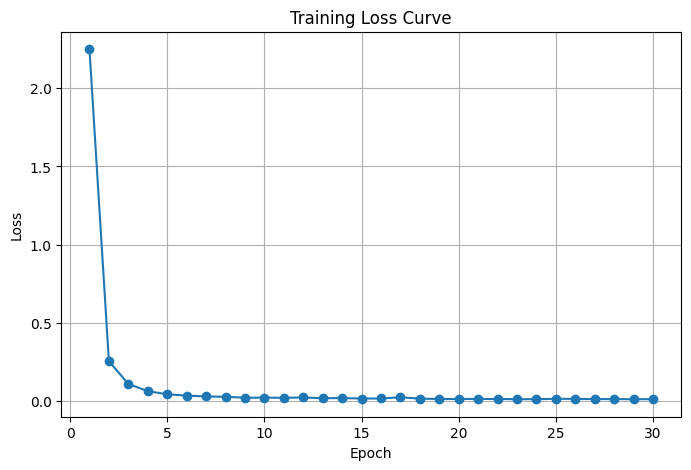

In [86]:
# plotting training loss

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    marker = 'o'
)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

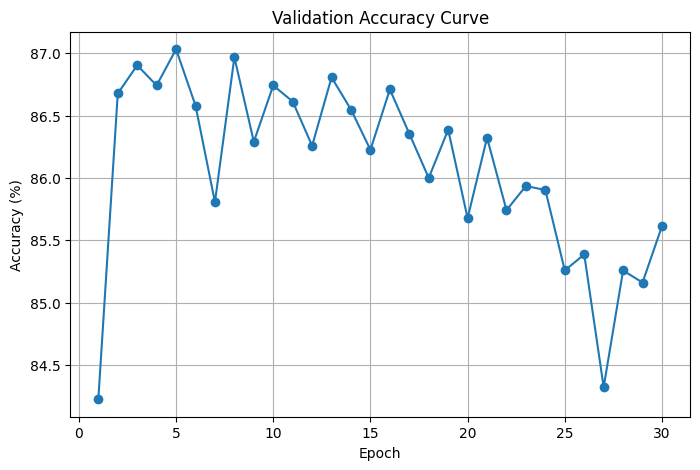

In [87]:
# validation accuracy

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(val_accuracies)+1),
    val_accuracies,
    marker = 'o'
)

plt.title("Validation Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

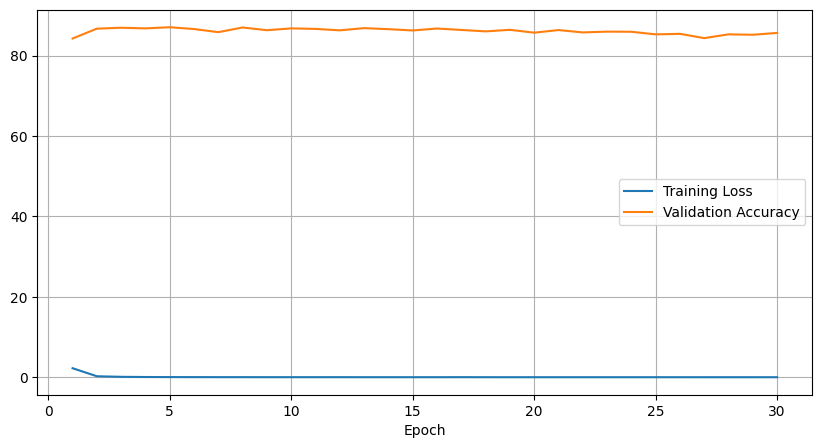

In [88]:
# plotting both together

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    label = "Training Loss"
)

plt.plot(
    range(1, len(val_accuracies)+1),
    val_accuracies,
    label = "Validation Accuracy"
)

plt.xlabel("Epoch")

plt.legend()

plt.grid(True)

plt.show()

**Results so far**

| Model               | Validation Accuracy |
| ------------------- | ------------------: |
| Logistic Regression |          **87.45%** |
| MLP Neural Network  |          **85.97%** |

</br>

Difference:
```
87.45 - 85.97 = 1.48%
```

</br>

observation:
```
Epoch 1: 2.2183
Epoch 10: 0.0242
Epoch 20: 0.0135
Epoch 30: 0.0097
```
training loss became extremely small, that means **The neural network learned the training set very well.** Yet the MLP model did not surpasst the Logistic Regression model.

</br>

Overfitting happening:

The model is becoming increasingly confident on training data, but that confidence is not translating into better generalization.

</br>

**Why Can Logistic Regression Beat a Neural Network Here?**
This is one of the most famous lessons in NLP.
TF-IDF vectors are:
- Very high-dimensional
- Sparse
- Often linearly separable
For this kind of feature representation: **Logistic Regression is incredibly strong.**

In fact, for many years, TF-IDF + Logistic Regression was the industry standard for text classification.

</br>

**What is happening?**

Logistic Regression learns direct associations. that is for example:
```
flight  → book_flight
password → reset_password
weather → get_weather
```
meanwhile the MLP neural network model is learning unnecessary complexity. TF-IDF has already done much of the feature engineering.

In [89]:
# Evaluation analysis

## Evaluation Prediction Loop
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for inputs, labels in val_loader:
        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [90]:
# Precision / Recall / F1-score

report = classification_report(
    all_labels,
    all_preds,
    target_names = class_names
)

print(report)

                           precision    recall  f1-score   support

       restaurant_reviews       1.00      0.65      0.79        20
           nutrition_info       0.82      0.45      0.58        20
          account_blocked       0.78      0.90      0.84        20
           oil_change_how       0.80      1.00      0.89        20
                     time       0.95      0.90      0.92        20
                  weather       0.77      0.85      0.81        20
           redeem_rewards       0.90      0.90      0.90        20
            interest_rate       1.00      0.95      0.97        20
                 gas_type       0.90      0.95      0.93        20
      accept_reservations       0.90      0.90      0.90        20
               smart_home       0.91      1.00      0.95        20
                user_name       0.75      0.90      0.82        20
         report_lost_card       1.00      0.95      0.97        20
                   repeat       0.95      0.90      0.92     

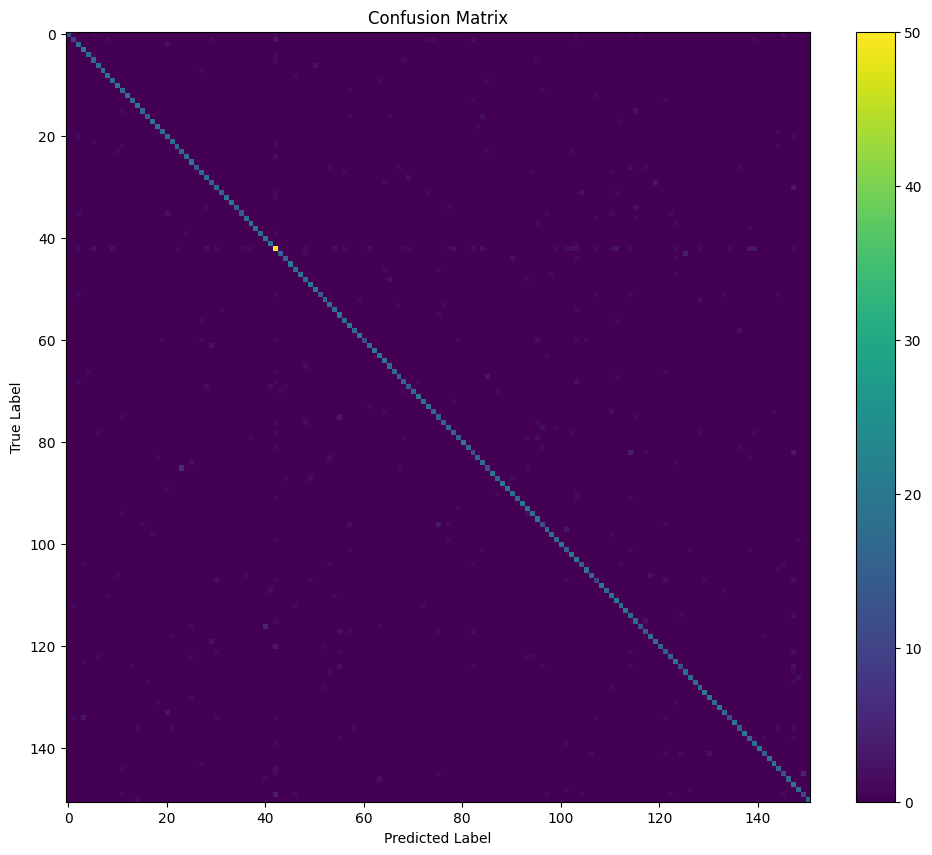

In [91]:
# Confusion Matrix

cm = confusion_matrix(all_labels, all_preds)


# Since 151 classes is huge, we will make a compact visualization.
plt.figure(figsize = (12,10))
plt.imshow(cm, aspect = 'auto')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.show()


In [92]:
# Error analysis

val_texts_raw = dataset["validation"]["text"]

wrong_samples = []

model.eval()
index = 0

with torch.no_grad():

    for inputs, labels in val_loader:
        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        batch_size = labels.size(0)

        for i in range(batch_size):
            true_label = labels[i].item()
            pred_label = predicted[i].item()

            if true_label != pred_label:
                wrong_samples.append({
                    "text": val_texts_raw[index],
                    "true": class_names[true_label],
                    "predicted": class_names[pred_label]
                })

            index += 1

In [93]:
len(wrong_samples)

446

##**Report**

The MLP achieved a peak validation accuracy of 87.06% at epoch 8. Further training reduced validation performance despite continued reductions in training loss, indicating overfitting. Logistic Regression ultimately achieved slightly better generalization performance (87.45%), suggesting that TF-IDF features are largely linearly separable for this intent classification task.

## BERT Fine-Tuning: DistilBERT

**DistilBERT** instead of full **BERT** to leverage less memory and easier training while achieving similar performance on intent classification

</br>

BERT stands for Bidirectional Encoder Representations from Transformers. It was created to replace architecture based on RNN, LTSM, GRU

**why transformers were revolutionary?**
suppose we have:
```
I booked a flight to Delhi.
```
RNN reads:
```
I → booked → a → flight → to → Delhi
```
one word at a time.

A Transformer processes:
```
I
booked
a
flight
to
Delhi
```
all at once. This allows it to learn relationships between any words in the sentence efficiently.

### TF-IDF vs BERT

**1. TF-IDF**

Sentence: ```I want to book a flight```

TF-IDF might produce:
| Word   | Score |
| ------ | ----- |
| book   | 0.72  |
| flight | 0.83  |
| want   | 0.22  |

The model sees:
```
book
flight
want
```
mostly as independent features.

Limitation

Consider: ```I want to book a flight```

and ```I want to read a book```

TF-IDF sees: `book` in both.

It has no understanding that: `book = reservation` in one sentence and `book = object` to read in another.

</br>

**2. BERT**

BERT creates a representation that depends on context.

The word: `book` gets different representations depending on surrounding words.

Example: `book a flight` and `read a book`

The vector for `book` will be different. This is one of the major breakthroughs of Transformers.

### Subword Tokenization

Example: `unbelievable`

BERT tokenizer might split into: `["un", "##believ", "##able"]` or something similar.

</br>

**Why?**

Because BERT cannot store every possible word in existence. Instead it stores: **subword vocabulary** which allows it to understand:
- new words
- rare words
- misspellings better

### What Changes in the Data Pipeline?

Current Pipeline:
```
            Text
              ↓
        Preprocessing
              ↓
            TF-IDF
              ↓
5000-dimensional sparse vector
              ↓
          Classifier
```

BERT Pipeline:
```
             Text
              ↓
        BERT Tokenizer
              ↓
          Token IDs
              ↓
      Transformer Layers
              ↓
      Contextual Embeddings
              ↓
        Classifier Head
              ↓
      Intent Prediction
```

### Concept

Right now your TF-IDF vector is something like: `[0.0, 0.3, 0.7, 0.0, ...]` A fixed feature vector.

With BERT, every word gets a learned contextual representation. Conceptually: `book` might become `[0.23, -0.44, 1.12, ...]` a vector with hundreds of dimensions. And that vector changes depending on context.

### What I am Really Testing

The project is about comparing three philosophies

**Model 1**
```
TF-IDF
+
Logistic Regression
```
**Question**: Can simple statistics classify intents?

**Result**: 87.45%

</br>

**Model 2**
```
TF-IDF
+
Neural Network
```
**Question**: Does a nonlinear classifier improve TF-IDF?

**Result**: 87.06%

</br>

**Model 3**
```
BERT
+
Classification Head
```

**Question**: Does contextual language understanding improve intent classification?

**Result**: ???

In [94]:
!pip install transformers datasets accelerate -q

In [112]:
import torch
from torch.utils.data import DataLoader

from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

In [96]:
# loading tokenizer associated with DistilBERT

checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [97]:
text = "I want to book a flight"
tokens = tokenizer(text)

print(tokens)

{'input_ids': [101, 1045, 2215, 2000, 2338, 1037, 3462, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}


- **input_ids**: Words/subwords converted to numbers.
- **token_type_ids**: tell the model which part of the input a token belongs to. 0 means it belongs to the first sequence(e.g Sequence A/Question) and 1 means it belongs to the second sequence(e.g Sequence B/Context/Answer)
- **attention_mask**: Tells the model which tokens are real. 1 means contains text, 0 means it is a padding

In [98]:
# determining number of labels

num_labels = len(dataset["train"].features["intent"].names)
num_labels

151

In [100]:
# retrieving label names

label_names = dataset["train"].features["intent"].names
label_names[:10]

['restaurant_reviews',
 'nutrition_info',
 'account_blocked',
 'oil_change_how',
 'time',
 'weather',
 'redeem_rewards',
 'interest_rate',
 'gas_type',
 'accept_reservations']

In [101]:
# building a tokenizer function

def tokenize_function(example):
  '''
  equivalent of TF-IDF tokenizer
  '''

  return tokenizer(
      example["text"],
      truncation = True, # if a sentence is too long for example 200 words, cut it to 64 tokens
      padding = "max_length", # all sequence becomes 64 tokens. this allows batching
      max_length = 64 # most CLINC150 utterances are short so 64 is enough
  )

In [102]:
# applying tokenization

tokenized_dataset = dataset.map(tokenize_function, batched = True)

Map:   0%|          | 0/15250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3100 [00:00<?, ? examples/s]

Map:   0%|          | 0/5500 [00:00<?, ? examples/s]

In [103]:
tokenized_dataset["train"][0]

{'text': 'what expression would i use to say i love you if i were an italian',
 'intent': 61,
 'input_ids': [101,
  2054,
  3670,
  2052,
  1045,
  2224,
  2000,
  2360,
  1045,
  2293,
  2017,
  2065,
  1045,
  2020,
  2019,
  3059,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
 

In [ ]:
# renaming labels
## transformers expect labels not intent

In [104]:
tokenized_dataset = tokenized_dataset.rename_column("intent", "labels")

In [105]:
tokenized_dataset["train"][0]

{'text': 'what expression would i use to say i love you if i were an italian',
 'labels': 61,
 'input_ids': [101,
  2054,
  3670,
  2052,
  1045,
  2224,
  2000,
  2360,
  1045,
  2293,
  2017,
  2065,
  1045,
  2020,
  2019,
  3059,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
 

In [106]:
# setting tensor format
## returning sample as tensors

tokenized_dataset.set_format(
    type = "torch",
    columns = ["input_ids", "attention_mask", "labels"]
)

In [107]:
len(tokenized_dataset)

3

In [108]:
len(tokenized_dataset["train"])

15250

In [109]:
tokenized_dataset["train"][0]

{'labels': tensor(61),
 'input_ids': tensor([ 101, 2054, 3670, 2052, 1045, 2224, 2000, 2360, 1045, 2293, 2017, 2065,
         1045, 2020, 2019, 3059,  102,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}

In [111]:
type(tokenized_dataset["train"][0]), type(tokenized_dataset["train"][0]["input_ids"])

(dict, torch.Tensor)

In [113]:
# creating dataloaders

train_loader = DataLoader(
    tokenized_dataset["train"],
    batch_size = 16,
    shuffle = True
)

val_loader = DataLoader(
    tokenized_dataset["validation"],
    batch_size = 16
)

In [128]:
# loading DistilBERT classifier
## building DistilBERT + classification head(automatically create the 151 intent classes)

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels = num_labels
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [129]:
# setting device agnostic

device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [130]:
model.to(device)

# should verify in the print if num_labels is now to 151 labels
# also verify that tokenized_dataset["train"][0] has input_ids, attention_mask and labels

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [134]:
tokenized_dataset["train"][0]

{'text': 'what expression would i use to say i love you if i were an italian',
 'labels': 61,
 'input_ids': [101,
  2054,
  3670,
  2052,
  1045,
  2224,
  2000,
  2360,
  1045,
  2293,
  2017,
  2065,
  1045,
  2020,
  2019,
  3059,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'token_type_ids': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
 

When I run `model.to(device)`, I am telling PyTorch to move the model weights to the GPU. Right after that, I try to access tokenized_dataset["train"][0].

Because the model is now set up for PyTorch (`device = "cuda"`), Hugging Face's datasets library automatically tries to format the dataset's output into PyTorch Tensors so they match the model. It is during this automatic conversion phase that it triggers the `torch_formatter.py` script, checks the `torchvision` installation, and crashes on that `VideoReader bug.

Since I am doing intent classification with DistilBERT, I don't need `torchvision`'s video utilities.

In [137]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [142]:
# fixing the issue

# 1. clearing the broken automatic format
tokenized_dataset.reset_format()

# 2. reinspecting data
sample = tokenized_dataset["train"][0]

print(sample.keys())

dict_keys(['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'])


In [143]:
print(sample["input_ids"][:10])
print(sample["attention_mask"][:10])
print(sample["labels"])

[101, 2054, 3670, 2052, 1045, 2224, 2000, 2360, 1045, 2293]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
61


In [144]:
sample = tokenized_dataset["train"][0]

print("Text:")
print(sample["text"])

print("\nLabel:")
print(sample["labels"])

print("\nInput Length:")
print(len(sample["input_ids"]))

Text:
what expression would i use to say i love you if i were an italian

Label:
61

Input Length:
64


our tokenized_dataset is no longer a torch.Tensor is back to be a dict due to for having reset the format.

As `reset_format()` keep the dataset as lists. As long as we use `DataCollatorWithPadding` when setting up the `Trainer`, the training loop will run perfectly. This completely bypasses the broken `torchvision` check.

In [149]:
# recreating DataLoaders since we avoid the set_format(type = torch) issue

from transformers import DataCollatorWithPadding

# Removing the 'text' column as it is not needed for the model input
# and causes issues when the DataCollatorWithPadding tries to convert strings to tensors.
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

data_collator = DataCollatorWithPadding(
    tokenizer = tokenizer
)

train_loader = DataLoader(
    tokenized_dataset["train"],
    batch_size = 16,
    shuffle = True,
    collate_fn = data_collator
)

val_loader = DataLoader(
    tokenized_dataset["validation"],
    batch_size = 16,
    collate_fn = data_collator
)

In [151]:
print(f"Number of batches in train_loader: {len(train_loader)}")

# inspecting the shape of items within a batch:
for batch in train_loader:
    print(f"Shape of input_ids in a batch: {batch['input_ids'].shape}")
    print(f"Shape of attention_mask in a batch: {batch['attention_mask'].shape}")
    print(f"Shape of labels in a batch: {batch['labels'].shape}")
    break # only printing for the first batch

Number of batches in train_loader: 954
Shape of input_ids in a batch: torch.Size([16, 64])
Shape of attention_mask in a batch: torch.Size([16, 64])
Shape of labels in a batch: torch.Size([16])


In [155]:
batch = next(iter(train_loader))

print(batch.keys())
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

KeysView({'labels': tensor([123, 131,  10,  99,  96, 111, 121, 129, 133, 149,  11,  19, 110,   3,
        144,  24]), 'input_ids': tensor([[  101,  2129,  2146,  ...,     0,     0,     0],
        [  101,  2029, 15893,  ...,     0,     0,     0],
        [  101,  3531,  4638,  ...,     0,     0,     0],
        ...,
        [  101,  2507,  2033,  ...,     0,     0,     0],
        [  101,  2111,  2655,  ...,     0,     0,     0],
        [  101,  2003,  1996,  ...,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])})
torch.Size([16, 64])
torch.Size

In [156]:
print(tokenizer.name_or_path)

distilbert-base-uncased


In [157]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels = num_labels
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [158]:
print(model.config.num_labels)

151


In [159]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [160]:
print(device)

cuda


In [162]:
# defining optimizer
## For BERT-family models i should use AdamW

from torch.optim import AdamW

optimizer = AdamW(params = model.parameters(), lr = 2e-5)

**Why Such a Small Learning Rate?**

For MLP: `0.001`

For BERT: `0.00002`

Because:

We are **fine-tuning a pretrained model**, not learning from scratch. And large learning rates can destroy pretrained knowledge.

In [166]:
# first forward pass before the actual training
'''
verifying:
DataLoader
GPU
Model
Loss
Logits
'''

batch = next(iter(train_loader))

batch = {k: v.to(device) for k, v in batch.items()}

outputs = model(
    input_ids = batch["input_ids"],
    attention_mask = batch["attention_mask"],
    labels = batch["labels"]
)

In [169]:
print(outputs.loss)
print(outputs.logits.shape)

tensor(5.0455, device='cuda:0', grad_fn=<NllLossBackward0>)
torch.Size([16, 151])


there is a **oos** intent label, it stands for "out of scope" it is important because In production chatbots, users often ask things that are not supported.

that is why there is 151 labels

**Important concept before Training**:

With the MLP, we trained for: `30 epochs`

With DistilBERT, we typically do: `2-5 epochs` not `30`.

</br>

Because we're not learning language from scratch. We're only slightly adjusting a pretrained model. Training too long can cause: **catastrophic forgetting**, where the model starts losing some of the useful knowledge acquired during pretraining.

In [170]:
# defining hyperparameters

batch_size = 16
learning_rate = 2e-5
epochs = 3

In [171]:
# validation function

def evaluate(model, dataloader, device):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items() if k != "token_type_ids"}

            outputs = model(
                input_ids = batch["input_ids"],
                attention_mask = batch["attention_mask"]
            )

            predictions = outputs.logits.argmax(dim = 1)

            correct += (predictions == batch["labels"]).sum().item()

            total += batch["labels"].size(0)

    return 100 * correct / total

In [172]:
# defining tracking lists

train_losses = []
val_accuracies = []

In [173]:
# training loop

num_epochs = 3

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items() if k != "token_type_ids"}

        optimizer.zero_grad()

        outputs = model(
            input_ids = batch["input_ids"],
            attention_mask = batch["attention_mask"],
            labels = batch["labels"]
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    val_acc = evaluate(
        model,
        val_loader,
        device
    )

    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 1/3 | Loss: 3.0758 | Val Acc: 88.32%
Epoch 2/3 | Loss: 0.5846 | Val Acc: 93.29%
Epoch 3/3 | Loss: 0.1679 | Val Acc: 94.23%
